# E07 Matrix Factorization Rank-Initialization Phase Diagram

### Problem

This notebook studies a Matrix Factorization phase diagram over factor rank and initialization scale. The target matrix is generated as

$$X^\star=U\operatorname{diag}(s_1,\ldots,s_d)V^\top,$$

where $U,V$ come from Gaussian QR factors. The true rank is fixed at $r=5$, while the factor rank $q$ varies independently. The represented matrix and objective are

$$\widehat X=LR^\top,\qquad g(L,R)=\frac{1}{2d^2}\lVert LR^\top-X^\star\rVert_F^2,$$

with $L,R\in\mathbb{R}^{d\times q}$. The initialization scale is $s$:

$$L_0=sG_L,\qquad R_0=sG_R,\qquad G_L[j,k],G_R[j,k]\overset{\mathrm{i.i.d.}}{\sim}\mathcal{N}(0,1).$$

The grid varies

$$q\in\{3,5,10,20\},\qquad s\in\{10^{-4},3\cdot10^{-4},10^{-3},3\cdot10^{-3},10^{-2},3\cdot10^{-2},10^{-1},3\cdot10^{-1}\}.$$

The spectrum cases are `hard-k1` and `exp-k100`; under `kappa=100`, the nonzero target singular values span condition number $100$.

The experiment fixes $d=60$, true rank $r=5$, and the factorized objective; it varies factor rank $q$, initialization scale $s$, target conditioning, optimizer, and seed. Its purpose is to separate underparameterization effects from initialization-scale effects and optimizer effects.

When reading the results, focus first on recovery heatmaps over $(q,s)$, then compare Muon-vs-baseline gap heatmaps and divergence rates. Balancedness and effective rank help explain whether a low product error also corresponds to a well-scaled factorization. Each step costs $\Theta(d^2q)$ plus optimizer overhead, and the full grid can execute up to $32000000$ optimization steps.

## Implementation Details: Skip Unless Modifying The Experiment

The code below is visible for reproducibility. A reader can skip it unless changing the grid, optimizer definitions, stopping rule, diagnostics, or plotting calls.

In [1]:
import math
import os
import pathlib
import sys
import time
for name in ["OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"]:
    os.environ.setdefault(name, "1")

import IPython.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT = pathlib.Path.cwd().resolve()
if not (PROJECT / "problems").exists():
    PROJECT = PROJECT.parent.resolve()
sys.path.insert(0, str(PROJECT))

import optimizers
import plotting
import problems.MatrixConstruction
import problems.MatrixFactorization
import util
import util.diagnostics

torch.set_default_dtype(torch.float64)
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

print(f"project = {PROJECT}")
print(f"torch   = {torch.__version__}")


project = /Users/tianyangliu/Desktop/muonexperiment
torch   = 2.11.0


/opt/anaconda3/envs/muonexperiment-torch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Parameters And Runs


In [2]:
NOTEBOOK_ID = "E07 MF rank-init phase"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE_NAME = "float64"
ALGOS = ["Muon", "Muon-Exact", "Shampoo", "Adam", "SGD"]
SEEDS = list(range(50))
SMOKE_TEST = False
SMOKE_TEST_MAX_STEPS = 10
FULL_ITERS = 2000

BASE_SPEC = dict(
    problem="MatrixFactorization",
    d=60,
    rank=5,
    lr=0.01,
    iters=SMOKE_TEST_MAX_STEPS if SMOKE_TEST else FULL_ITERS,
    early_stop=True,
    early_stop_min_steps=100,
    early_stop_patience=20,
    early_stop_min_delta=1e-4,
    device_type=DEVICE.type,
    dtype_name=DTYPE_NAME,
)
SPECTRUM_CASES = [
    dict(spectrum_case="hard-k1", spectrum="hard-cutoff", kappa=1.0),
    dict(spectrum_case="exp-k100", spectrum="exponential-decay", kappa=100.0),
]
FACTOR_RANKS = [3, 5, 10, 20]
INIT_SCALES = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1]
NUM_WORKERS = min(8, os.cpu_count() or 1)
JOBLIB_BACKEND = "loky"

runs = pd.DataFrame([
    {**BASE_SPEC, **case, "factor_rank": factor_rank, "init_scale": init_scale, "left_scale": init_scale, "right_scale": init_scale, "algo": algo, "seed": seed}
    for case in SPECTRUM_CASES
    for factor_rank in FACTOR_RANKS
    for init_scale in INIT_SCALES
    for algo in ALGOS
    for seed in SEEDS
])
runs.insert(0, "run_id", range(len(runs)))

print(f"device={DEVICE}, workers={NUM_WORKERS}, backend={JOBLIB_BACKEND}")
print(f"smoke_test={SMOKE_TEST}, steps_per_run={BASE_SPEC['iters']}")
print(f"runs={len(runs)}, max_total_steps={len(runs) * BASE_SPEC['iters']}")
IPython.display.display(runs)


device=cpu, workers=8, backend=loky
smoke_test=False, steps_per_run=2000
runs=1600, max_total_steps=3200000


,run_id,problem,d,rank,lr,iters,early_stop,early_stop_min_steps,early_stop_patience,early_stop_min_delta,...,dtype_name,spectrum_case,spectrum,kappa,factor_rank,init_scale,left_scale,right_scale,algo,seed
0,0,MatrixFactorization,60,5,0.01,2000,True,100,20,0.0001,...,float64,hard-k1,hard-cutoff,1.0,3,0.0001,0.0001,0.0001,Muon,0
1,1,MatrixFactorization,60,5,0.01,2000,True,100,20,0.0001,...,float64,hard-k1,hard-cutoff,1.0,3,0.0001,0.0001,0.0001,Muon,1
2,2,MatrixFactorization,60,5,0.01,2000,True,100,20,0.0001,...,float64,hard-k1,hard-cutoff,1.0,3,0.0001,0.0001,0.0001,Muon,2
3,3,MatrixFactorization,60,5,0.01,2000,True,100,20,0.0001,...,float64,hard-k1,hard-cutoff,1.0,3,0.0001,0.0001,0.0001,Muon,3
4,4,MatrixFactorization,60,5,0.01,2000,True,100,20,0.0001,...,float64,hard-k1,hard-cutoff,1.0,3,0.0001,0.0001,0.0001,Muon,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,1595,MatrixFactorization,60,5,0.01,2000,True,100,20,0.0001,...,float64,exp-k100,exponential-decay,100.0,20,0.3000,0.3000,0.3000,SGD,0
1596,1596,MatrixFactorization,60,5,0.01,2000,True,100,20,0.0001,...,float64,exp-k100,exponential-decay,100.0,20,0.3000,0.3000,0.3000,SGD,1
1597,1597,MatrixFactorization,60,5,0.01,2000,True,100,20,0.0001,...,float64,exp-k100,exponential-decay,100.0,20,0.3000,0.3000,0.3000,SGD,2
1598,1598,MatrixFactorization,60,5,0.01,2000,True,100,20,0.0001,...,float64,exp-k100,exponential-decay,100.0,20,0.3000,0.3000,0.3000,SGD,3


### Pseudocode

```text
for each target spectrum, factor rank, initialization scale, optimizer, seed:
    build X_star
    initialize L and R with the same scale
    define step(state): factorization loss -> backward -> optimizer.step -> recovery/balancedness metrics
    repeat step until max iterations, divergence, or patience early stopping
summarize the final relative matrix error over the rank-init grid
```

Runtime grows as `spectra * factor_ranks * init_scales * optimizers * seeds * iterations`.


### Worker Definition


In [3]:
def dtype_from_name(dtype_name):
    dtype = getattr(torch, dtype_name)
    if not isinstance(dtype, torch.dtype):
        raise ValueError(f"unknown torch dtype: {dtype_name}")
    return dtype


def configure_torch(dtype):
    torch.set_default_dtype(dtype)
    torch.set_num_threads(1)
    try:
        torch.set_num_interop_threads(1)
    except RuntimeError:
        pass


def make_optimizer(algo, params, lr, rank):
    if algo == "Muon" and hasattr(torch.optim, "Muon"):
        try:
            return torch.optim.Muon(params, lr=lr, weight_decay=0.0, momentum=0.9, nesterov=False, ns_steps=5)
        except TypeError:
            pass
    if algo == "Muon":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="newton_schulz", ns_steps=5)
    if algo in {"Muon-Exact", "MuonExact"}:
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="exact")
    if algo == "Muon-NS-1":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="newton_schulz", ns_steps=1)
    if algo == "Muon-NS-10":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="newton_schulz", ns_steps=10)
    if algo == "Muon-Truncated":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="truncated", rank=rank)
    if algo == "Muon-RandSVD":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="randsvd", rank=rank, oversample=5, power_iters=1)
    if algo == "Shampoo":
        return optimizers.Shampoo(params, lr=lr, beta2=0.9, epsilon=1e-8)
    if algo == "Adam":
        return torch.optim.Adam(params, lr=lr)
    if algo == "SGD":
        return torch.optim.SGD(params, lr=lr, momentum=0.9)
    if algo == "NormalizedSGD":
        return optimizers.NormalizedSGD(params, lr=lr, momentum=0.9, norm_type="fro")
    if algo == "SpectralNormSGD":
        return optimizers.NormalizedSGD(params, lr=lr, momentum=0.9, norm_type="spectral")
    if algo == "LayerwiseNormalizedSGD":
        return optimizers.NormalizedSGD(params, lr=lr, momentum=0.9, norm_type="fro")
    raise ValueError(f"unknown algo: {algo}")


def show_figure(fig):
    IPython.display.display(fig)
    plt.close(fig)


def single_run(run):
    run = dict(run)
    d = int(run["d"])
    rank = int(run["rank"])
    factor_rank = int(run["factor_rank"])
    seed = int(run["seed"])
    iters = int(run["iters"])
    early_stop = bool(run["early_stop"])
    early_stop_min_steps = int(run["early_stop_min_steps"])
    early_stop_patience = int(run["early_stop_patience"])
    early_stop_min_delta = float(run["early_stop_min_delta"])
    device = torch.device(run["device_type"])
    dtype = dtype_from_name(run["dtype_name"])
    configure_torch(dtype)

    problem = problems.MatrixFactorization.make_matrix_factorization_problem(
        d,
        rank,
        spectrum=run["spectrum"],
        kappa=float(run["kappa"]),
        seed=seed,
        device=device,
        dtype=dtype,
        factor_rank=factor_rank,
    )
    left = torch.nn.Parameter(
        problems.MatrixConstruction.randn((d, factor_rank), seed + 3000, device, dtype) * float(run["left_scale"])
    )
    right = torch.nn.Parameter(
        problems.MatrixConstruction.randn((d, factor_rank), seed + 4000, device, dtype) * float(run["right_scale"])
    )
    params = [left, right]
    optimizer = make_optimizer(run["algo"], params, float(run["lr"]), rank)
    initial_loss = float(problem.loss(left, right).detach().cpu())
    best_loss = None
    early_stop_wait = 0
    rows = []
    start_time = time.perf_counter()

    def step():
        optimizer.zero_grad(set_to_none=True)
        loss = problem.loss(left, right)
        loss.backward()
        grad_norms = torch.stack([param.grad.detach().norm() for param in params])
        grad_norm = float(torch.linalg.vector_norm(grad_norms).cpu())
        optimizer.step()
        return float(loss.detach().cpu()), grad_norm

    for _ in range(iters):
        loss_value, grad_norm = step()
        if best_loss is None:
            best_loss = loss_value
        elif best_loss - loss_value >= early_stop_min_delta:
            best_loss = loss_value
            early_stop_wait = 0
        else:
            early_stop_wait += 1

        estimate = left.detach() @ right.detach().T
        stop_reason = ""
        if not math.isfinite(loss_value) or loss_value > max(1e6, 1e6 * max(initial_loss, 1e-12)):
            stop_reason = "diverged"
        elif early_stop and len(rows) + 1 >= early_stop_min_steps and early_stop_wait >= early_stop_patience:
            stop_reason = "early_stop_patience"

        rows.append({
            **run,
            "initial_loss": initial_loss,
            "step": len(rows) + 1,
            "loss": loss_value,
            "grad_norm": grad_norm,
            "relative_matrix_error": util.diagnostics.relative_matrix_error(estimate, problem.target),
            "left_norm": float(left.detach().norm().cpu()),
            "right_norm": float(right.detach().norm().cpu()),
            "product_norm": float(estimate.norm().cpu()),
            "balancedness": util.diagnostics.balancedness(left, right),
            "best_loss": best_loss,
            "early_stop_wait": early_stop_wait,
            "elapsed_s": time.perf_counter() - start_time,
            "stop_reason": stop_reason,
        })
        if stop_reason:
            break

    if rows:
        estimate = left.detach() @ right.detach().T
        rows[-1]["solution_effective_rank"] = util.diagnostics.effective_rank(estimate)
        if not rows[-1]["stop_reason"]:
            rows[-1]["stop_reason"] = "max_iters"
    return pd.DataFrame(rows)


## Results

The execute cell materializes the long per-step `runs` table. The saved outputs below are the experimental results to inspect.

In [4]:
runs = util.run_experiments(
    runs,
    single_run,
    num_workers=NUM_WORKERS,
    backend=JOBLIB_BACKEND,
    algo_order=ALGOS,
    sort_columns=("run_id", "step"),
    desc=NOTEBOOK_ID,
)
IPython.display.display(runs)


E07 MF rank-init phase:   0%|          | 0/1600 [00:00<?, ?run/s]

E07 MF rank-init phase:   0%|          | 1/1600 [00:02<58:28,  2.19s/run]

E07 MF rank-init phase:   0%|          | 3/1600 [00:02<16:29,  1.61run/s]

E07 MF rank-init phase:   0%|          | 5/1600 [00:02<08:42,  3.05run/s]

E07 MF rank-init phase:   1%|          | 11/1600 [00:02<03:02,  8.69run/s]

...

E07 MF rank-init phase:  98%|█████████▊| 1560/1600 [00:13<00:00, 162.48run/s]

E07 MF rank-init phase:  99%|█████████▊| 1578/1600 [00:13<00:00, 145.85run/s]

E07 MF rank-init phase: 100%|█████████▉| 1594/1600 [00:14<00:00, 69.44run/s] 

E07 MF rank-init phase: 100%|██████████| 1600/1600 [00:14<00:00, 113.25run/s]

,run_id,problem,d,rank,lr,iters,early_stop,early_stop_min_steps,early_stop_patience,early_stop_min_delta,...,relative_matrix_error,left_norm,right_norm,product_norm,balancedness,best_loss,early_stop_wait,elapsed_s,stop_reason,solution_effective_rank
0,0,MatrixFactorization,60,5,0.01,2000,True,100,20,0.0001,...,1.000025,0.058290,0.058407,0.001962,0.084622,0.000694,0,0.025110,,NaN
1,0,MatrixFactorization,60,5,0.01,2000,True,100,20,0.0001,...,0.998721,0.081869,0.078449,0.004421,0.052194,0.000694,1,0.025511,,NaN
2,0,MatrixFactorization,60,5,0.01,2000,True,100,20,0.0001,...,0.996053,0.150834,0.152581,0.014482,0.030083,0.000694,2,0.025783,,NaN
3,0,MatrixFactorization,60,5,0.01,2000,True,100,20,0.0001,...,0.991304,0.214411,0.216460,0.029386,0.018354,0.000694,3,0.026039,,NaN
4,0,MatrixFactorization,60,5,0.01,2000,True,100,20,0.0001,...,0.984100,0.283770,0.286193,0.050274,0.014019,0.000694,4,0.026281,,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224227,1599,MatrixFactorization,60,5,0.01,2000,True,100,20,0.0001,...,9.959531,8.787176,8.172252,13.598701,0.508103,0.026054,3,0.398680,,NaN
224228,1599,MatrixFactorization,60,5,0.01,2000,True,100,20,0.0001,...,9.957255,8.786589,8.171621,13.595566,0.508160,0.026054,4,0.398846,,NaN
224229,1599,MatrixFactorization,60,5,0.01,2000,True,100,20,0.0001,...,9.954981,8.786002,8.170990,13.592432,0.508217,0.026054,5,0.399019,,NaN
224230,1599,MatrixFactorization,60,5,0.01,2000,True,100,20,0.0001,...,9.952707,8.785416,8.170359,13.589300,0.508275,0.026054,6,0.399189,,NaN


### Result Tables


In [5]:
ordered_runs = runs.sort_values(["run_id", "step"])
dynamic_columns = [
    "step", "initial_loss", "loss", "grad_norm", "relative_matrix_error", "left_norm", "right_norm",
    "product_norm", "balancedness", "best_loss", "early_stop_wait", "elapsed_s", "stop_reason",
    "solution_effective_rank",
]
run_summary = ordered_runs.groupby("run_id", as_index=False).first().drop(columns=dynamic_columns, errors="ignore")
run_summary = run_summary.merge(
    ordered_runs.groupby("run_id", as_index=False).agg(
        initial_loss=("initial_loss", "first"),
        final_loss=("loss", "last"),
        min_loss=("loss", "min"),
        relative_matrix_error=("relative_matrix_error", "last"),
        min_relative_matrix_error=("relative_matrix_error", "min"),
        left_norm=("left_norm", "last"),
        right_norm=("right_norm", "last"),
        product_norm=("product_norm", "last"),
        balancedness=("balancedness", "last"),
        solution_effective_rank=("solution_effective_rank", "last"),
        actual_steps=("step", "last"),
        time_s=("elapsed_s", "last"),
        stop_reason=("stop_reason", "last"),
    ),
    on="run_id",
)
run_summary["time_per_step"] = run_summary["time_s"] / run_summary["actual_steps"].clip(lower=1)
run_summary["stopped_early"] = run_summary["stop_reason"].eq("early_stop_patience")
run_summary["diverged"] = run_summary["stop_reason"].eq("diverged")
run_summary["algo"] = pd.Categorical(run_summary["algo"], categories=ALGOS, ordered=True)
run_summary = run_summary.sort_values(["algo", "run_id"]).reset_index(drop=True)
run_summary["algo"] = run_summary["algo"].astype(str)
IPython.display.display(run_summary)


,run_id,problem,d,rank,lr,iters,early_stop,early_stop_min_steps,early_stop_patience,early_stop_min_delta,...,right_norm,product_norm,balancedness,solution_effective_rank,actual_steps,time_s,stop_reason,time_per_step,stopped_early,diverged
0,0,MatrixFactorization,60,5,0.01,2000,True,100,20,0.0001,...,1.710383,1.698388,0.023567,2.994996,100,0.051304,early_stop_patience,0.000513,True,False
1,1,MatrixFactorization,60,5,0.01,2000,True,100,20,0.0001,...,1.754338,1.727782,0.319812,2.998307,100,0.046979,early_stop_patience,0.000470,True,False
2,2,MatrixFactorization,60,5,0.01,2000,True,100,20,0.0001,...,1.753409,1.705256,0.057478,2.998248,100,0.049655,early_stop_patience,0.000497,True,False
3,3,MatrixFactorization,60,5,0.01,2000,True,100,20,0.0001,...,1.761372,1.717506,0.101233,2.999578,100,0.050245,early_stop_patience,0.000502,True,False
4,4,MatrixFactorization,60,5,0.01,2000,True,100,20,0.0001,...,1.712758,1.744822,0.053922,2.999180,100,0.059983,early_stop_patience,0.000600,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,1595,MatrixFactorization,60,5,0.01,2000,True,100,20,0.0001,...,8.547661,12.862672,0.543203,19.090590,2000,0.421684,max_iters,0.000211,False,False
1596,1596,MatrixFactorization,60,5,0.01,2000,True,100,20,0.0001,...,8.176415,12.757550,0.532424,19.148196,2000,0.415801,max_iters,0.000208,False,False
1597,1597,MatrixFactorization,60,5,0.01,2000,True,100,20,0.0001,...,8.255798,13.217859,0.519016,18.959596,2000,0.405860,max_iters,0.000203,False,False
1598,1598,MatrixFactorization,60,5,0.01,2000,True,100,20,0.0001,...,8.017569,13.682027,0.513170,18.931611,2000,0.410089,max_iters,0.000205,False,False


### Optimizer Recovery Heatmaps

The Problem cell defines a two-axis grid over factor rank $q$ and initialization scale $s$; these heatmaps are the recovery phase diagram on that grid.

Each generated figure fixes a target spectrum; within that figure, optimizer is the panel. The horizontal axis is initialization scale $s$, the vertical axis is factor rank $q$, and color is $\log_{10}$ of seed-median recovery error $e(\widehat X)=\lVert L_TR_T^\top-X^\star\rVert_F/\lVert X^\star\rVert_F$. The row $q<r$ is underparameterized, $q=r$ is correctly parameterized, and $q>r$ is overparameterized. Read this as a rank-scale phase diagram for each optimizer.

/Users/tianyangliu/Desktop/muonexperiment/plotting/phase.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


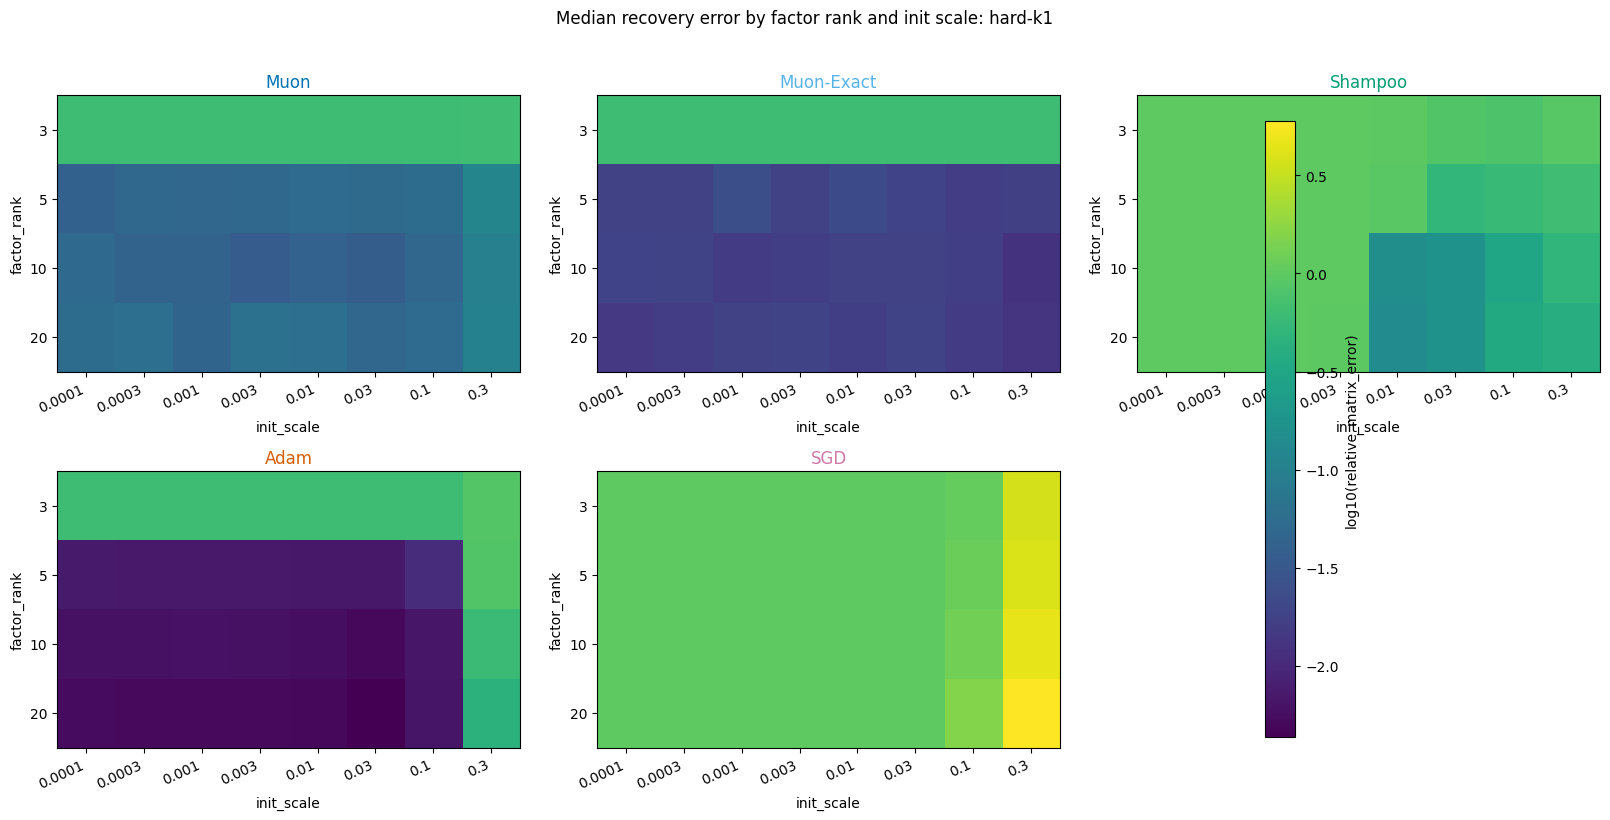

/Users/tianyangliu/Desktop/muonexperiment/plotting/phase.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


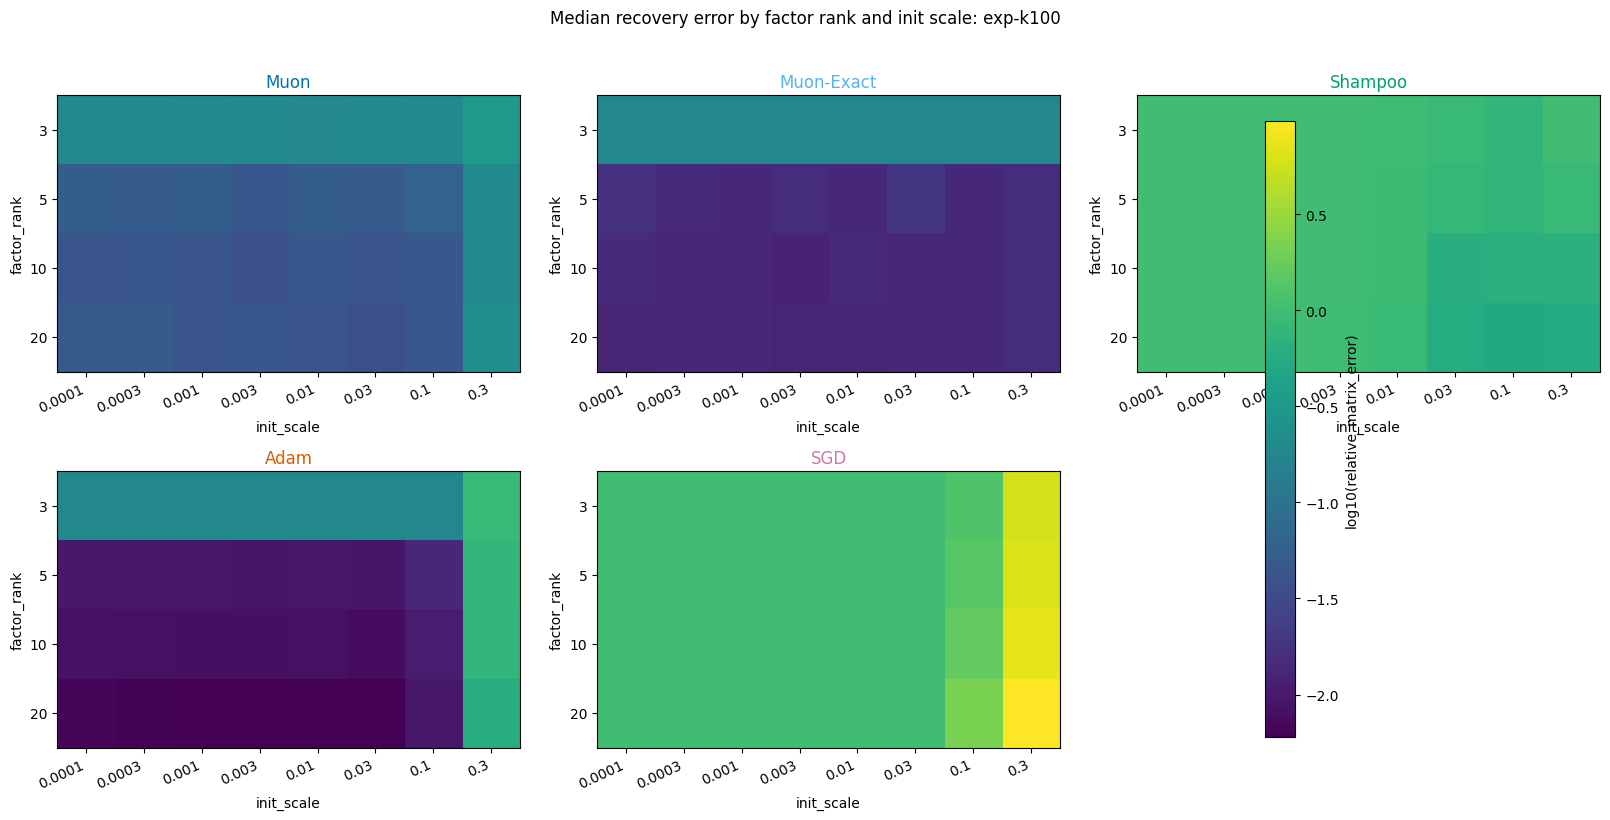

In [6]:
for spectrum_case in ["hard-k1", "exp-k100"]:
    fig, axes = plotting.plot_optimizer_heatmaps(
        run_summary[run_summary["spectrum_case"] == spectrum_case],
        x="init_scale",
        y="factor_rank",
        metric="relative_matrix_error",
        title=f"Median recovery error by factor rank and init scale: {spectrum_case}",
        log_color=True,
    )
    show_figure(fig)


### Muon Gap Heatmaps

The Problem cell asks how rank and scale affect optimizer behavior; these gap plots answer by comparing Muon to Adam and Shampoo at each $(q,s)$ cell.

These figures use the same factor-rank by initialization-scale grid, but color is a relative method gap rather than absolute error. For baseline $b$, the plotted value is $\Delta_{\mathrm{Muon},b}=\log_{10}(e_{\mathrm{Muon}})-\log_{10}(e_b)$. Negative cells favor Muon; positive cells favor the baseline. This isolates where Muon differs from Adam or Shampoo after controlling for rank, scale, and target spectrum.

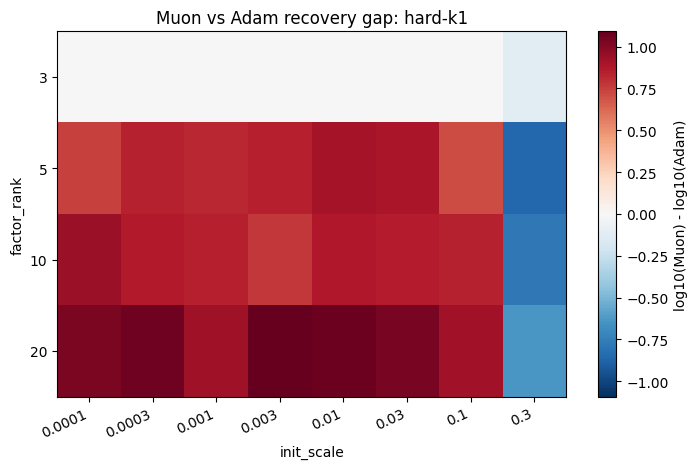

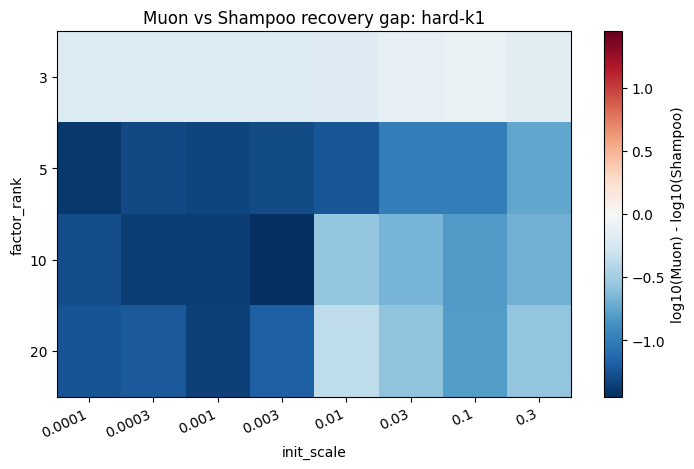

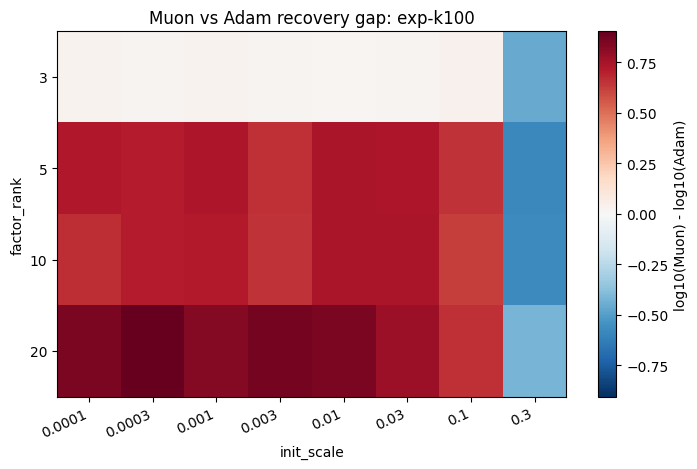

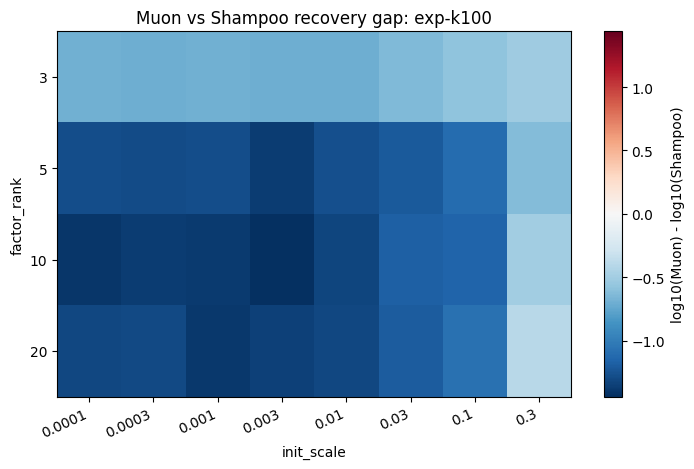

In [7]:
for spectrum_case in ["hard-k1", "exp-k100"]:
    sub = run_summary[run_summary["spectrum_case"] == spectrum_case]
    fig, ax = plotting.plot_gap_heatmap(
        sub,
        x="init_scale",
        y="factor_rank",
        metric="relative_matrix_error",
        left_algo="Muon",
        right_algo="Adam",
        title=f"Muon vs Adam recovery gap: {spectrum_case}",
    )
    show_figure(fig)
    fig, ax = plotting.plot_gap_heatmap(
        sub,
        x="init_scale",
        y="factor_rank",
        metric="relative_matrix_error",
        left_algo="Muon",
        right_algo="Shampoo",
        title=f"Muon vs Shampoo recovery gap: {spectrum_case}",
    )
    show_figure(fig)


### Divergence Heatmaps

The Problem cell includes regimes with underparameterization, overparameterization, tiny scale, and large scale; this plot marks where those regimes become numerically unstable.

These heatmaps show failure probability rather than accuracy. The horizontal axis is initialization scale $s$, the vertical axis is factor rank $q$, optimizer is the panel, and color is the seed average of the boolean `diverged` indicator. A bright cell means the method often left the numerically meaningful regime for that rank-scale combination, even if neighboring cells have good recovery.

/Users/tianyangliu/Desktop/muonexperiment/plotting/phase.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


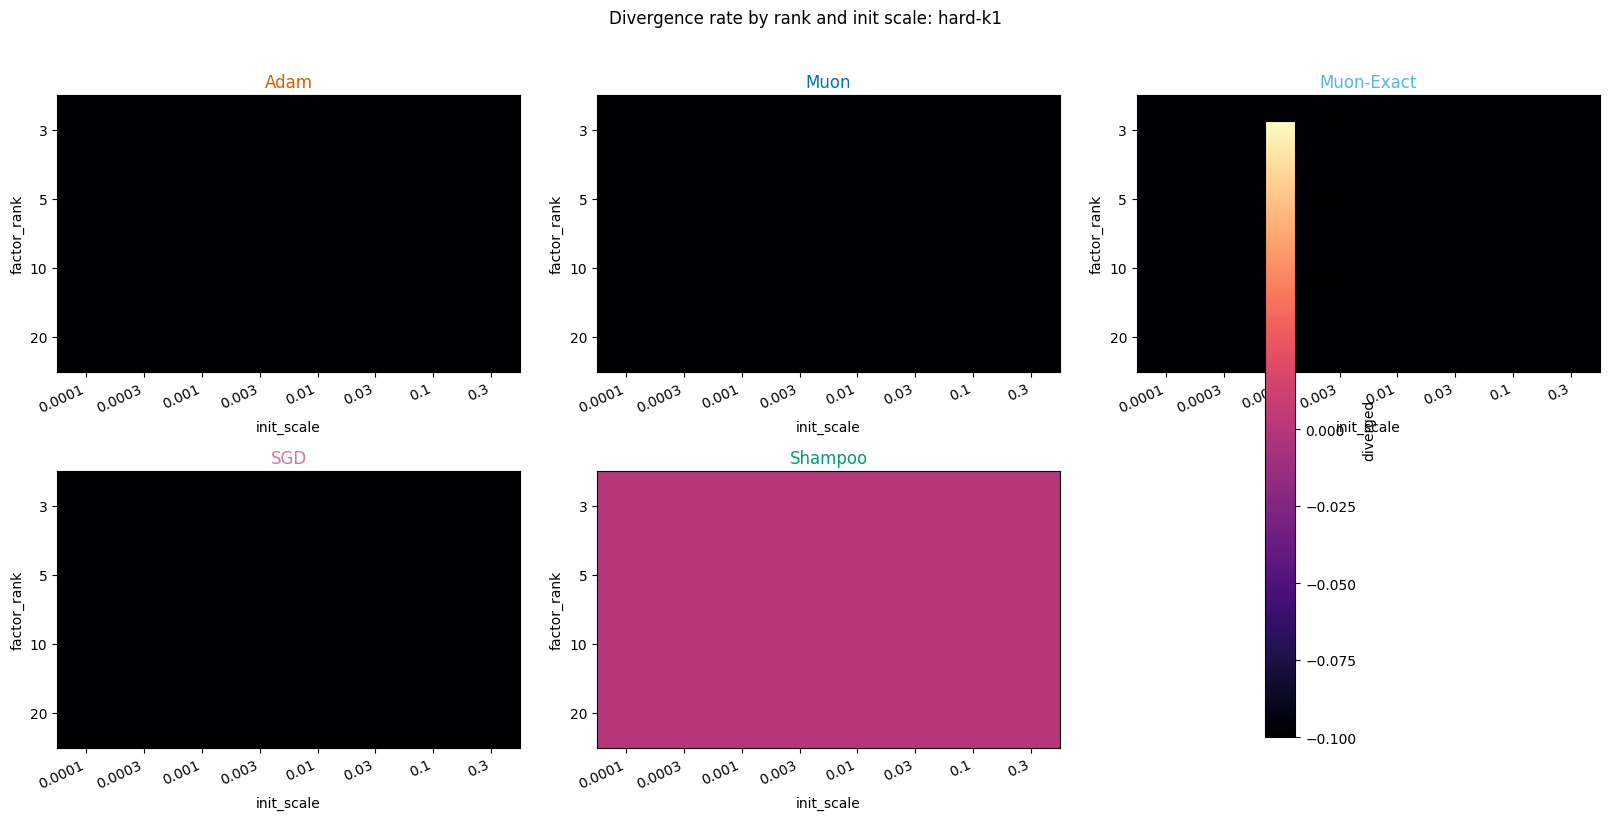

/Users/tianyangliu/Desktop/muonexperiment/plotting/phase.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


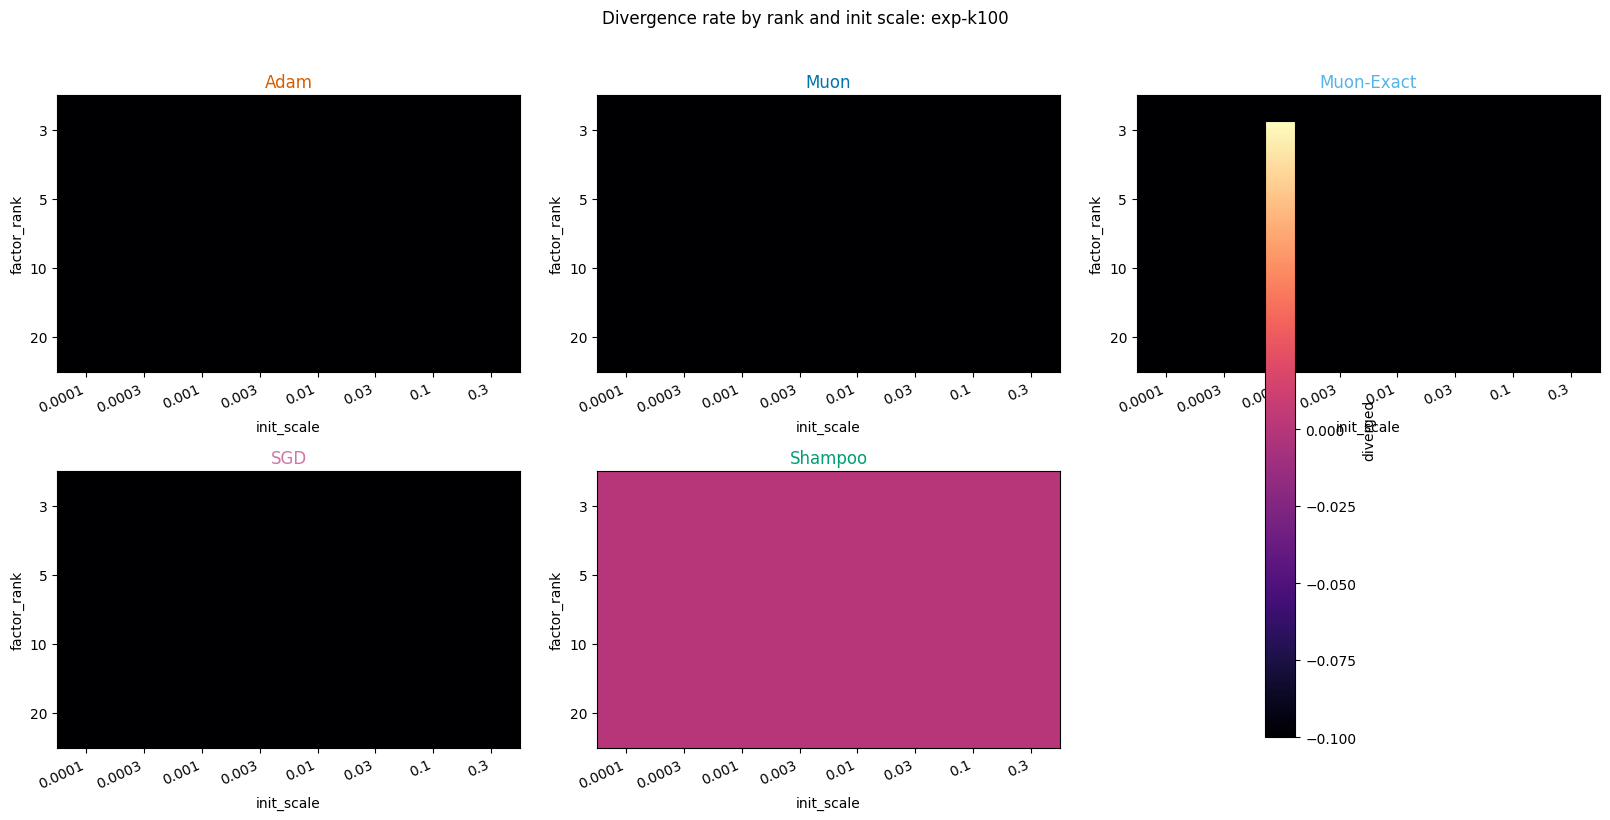

In [8]:
divergence = run_summary.groupby(["spectrum_case", "factor_rank", "init_scale", "algo"], as_index=False, observed=True)["diverged"].mean()
for spectrum_case in ["hard-k1", "exp-k100"]:
    fig, axes = plotting.plot_optimizer_heatmaps(
        divergence[divergence["spectrum_case"] == spectrum_case],
        x="init_scale",
        y="factor_rank",
        metric="diverged",
        title=f"Divergence rate by rank and init scale: {spectrum_case}",
        log_color=False,
        cmap="magma",
    )
    show_figure(fig)


### Representative Loss Curves

These panels choose concrete $(q,s)$ cells from the Problem grid and show the training dynamics behind the phase diagram.

The panels are representative cells from the rank-scale grid under the easy `hard-k1` spectrum: correct rank with standard scale, correct rank with tiny scale, overparameterized standard scale, and overparameterized large scale. The horizontal axis is step $t$, the vertical axis is seed-median factorization loss $g(L_t,R_t)$, and color is optimizer. Use these curves to understand the optimization paths behind the heatmap cells.

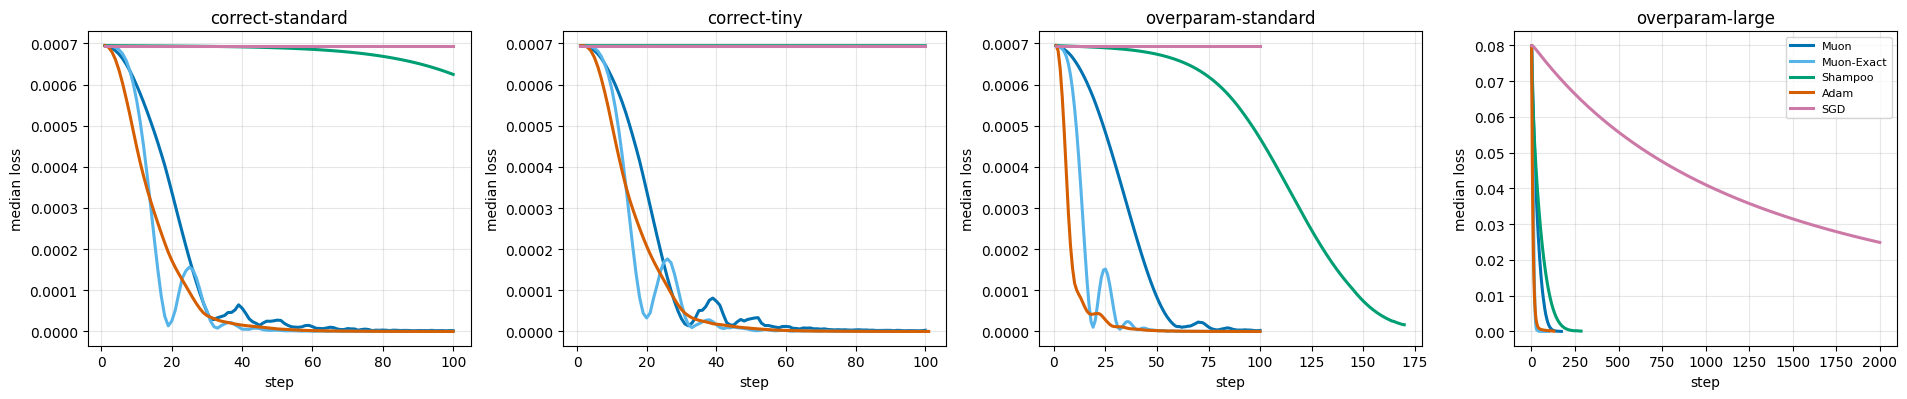

In [9]:
REPRESENTATIVE = [
    ("correct-standard", 5, 1e-2),
    ("correct-tiny", 5, 1e-4),
    ("overparam-standard", 20, 1e-2),
    ("overparam-large", 20, 3e-1),
]
fig, axes = plt.subplots(1, len(REPRESENTATIVE), figsize=(4.8 * len(REPRESENTATIVE), 4.1), sharey=False)
for ax, (label, factor_rank, init_scale) in zip(axes, REPRESENTATIVE):
    sub = runs[(runs["spectrum_case"] == "hard-k1") & (runs["factor_rank"] == factor_rank) & (runs["init_scale"] == init_scale)]
    for algo in ALGOS:
        curve = sub[sub["algo"] == algo].groupby("step", as_index=False)["loss"].median()
        ax.plot(curve["step"], curve["loss"], color=plotting.algorithm_color(algo), linewidth=2.2, label=algo)
    ax.set_title(label)
    ax.set_xlabel("step")
    ax.set_ylabel("median loss")
    ax.grid(alpha=0.3)
axes[-1].legend(fontsize=8)
fig.tight_layout()
show_figure(fig)


### Representative Log-Loss Curves

This is the same selected $(q,s)$ set from the Problem cell, but the log scale is better for reading convergence rates and small final losses.

This uses the same representative grid cells but puts the loss axis on a log scale. The visual dimensions are panel for `(q,s)`, horizontal axis for step, and color for optimizer. The log view is the primary view for convergence-rate and late-accuracy comparisons.

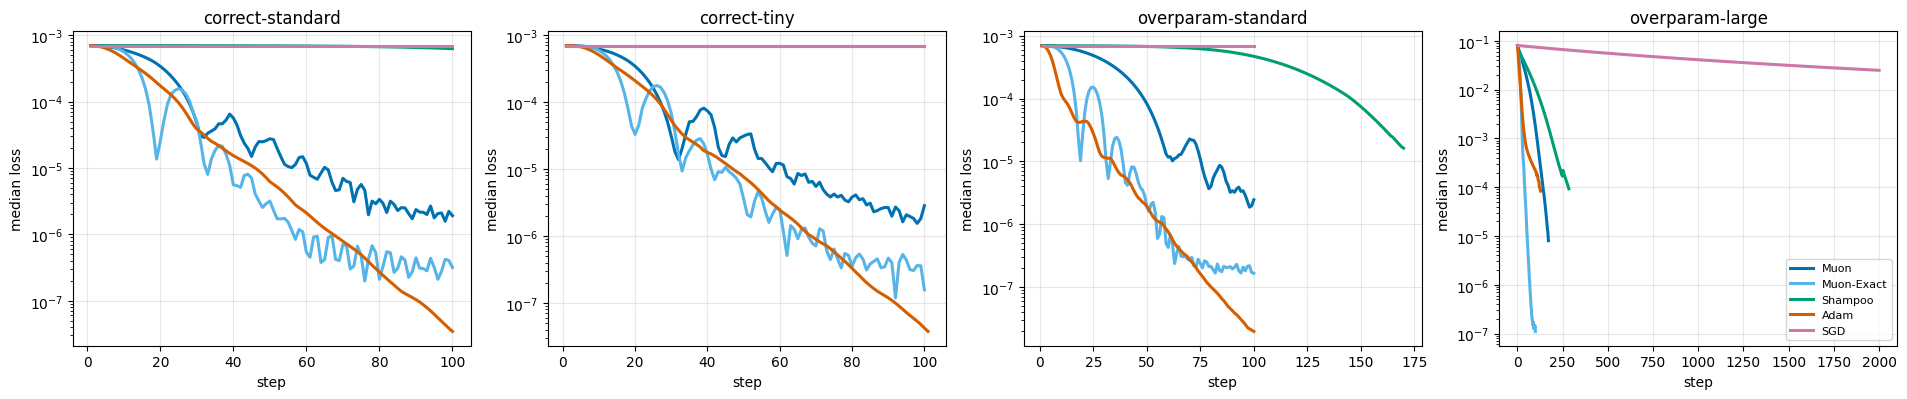

In [10]:
fig, axes = plt.subplots(1, len(REPRESENTATIVE), figsize=(4.8 * len(REPRESENTATIVE), 4.1), sharey=False)
for ax, (label, factor_rank, init_scale) in zip(axes, REPRESENTATIVE):
    sub = runs[(runs["spectrum_case"] == "hard-k1") & (runs["factor_rank"] == factor_rank) & (runs["init_scale"] == init_scale)]
    for algo in ALGOS:
        curve = sub[sub["algo"] == algo].groupby("step", as_index=False)["loss"].median()
        ax.plot(curve["step"], curve["loss"], color=plotting.algorithm_color(algo), linewidth=2.2, label=algo)
    ax.set_title(label)
    ax.set_xlabel("step")
    ax.set_ylabel("median loss")
    ax.set_yscale("log")
    ax.grid(alpha=0.3)
axes[-1].legend(fontsize=8)
fig.tight_layout()
show_figure(fig)


### Main Table


In [11]:
phase_table = run_summary.groupby(["spectrum_case", "factor_rank", "init_scale", "algo"], as_index=False, observed=True).agg(
    median_recovery=("relative_matrix_error", "median"),
    median_balancedness=("balancedness", "median"),
    median_effective_rank=("solution_effective_rank", "median"),
    divergence_rate=("diverged", "mean"),
)
best_by_setting = phase_table.sort_values("median_recovery").groupby(["spectrum_case", "factor_rank", "init_scale"], as_index=False, observed=True).first()
IPython.display.display(best_by_setting)


,spectrum_case,factor_rank,init_scale,algo,median_recovery,median_balancedness,median_effective_rank,divergence_rate
0,exp-k100,3,0.0001,Adam,0.187664,0.173744,2.891823,0.0
1,exp-k100,3,0.0003,Adam,0.187663,0.172866,2.891900,0.0
2,exp-k100,3,0.0010,Adam,0.187662,0.198010,2.891427,0.0
3,exp-k100,3,0.0030,Adam,0.187660,0.197711,2.891452,0.0
4,exp-k100,3,0.0100,Adam,0.187645,0.181944,2.891532,0.0
...,...,...,...,...,...,...,...,...
59,hard-k1,20,0.0030,Adam,0.005224,0.224475,5.184616,0.0
60,hard-k1,20,0.0100,Adam,0.005132,0.225663,5.176921,0.0
61,hard-k1,20,0.0300,Adam,0.004335,0.240848,5.140299,0.0
62,hard-k1,20,0.1000,Adam,0.006564,0.448965,5.276791,0.0


### Reading The Result

Read each heatmap horizontally for initialization-scale sensitivity and vertically for factor-rank sensitivity. Large Muon gaps at tiny scale indicate normalization-like behavior; large gaps at high factor rank indicate a nonconvex factor-geometry interaction.
